### Import the proper functions, and define helper functions

In [1]:
import sys, os
import matplotlib
import time
import pandas as pd
import numpy
import ast
import json
import matplotlib.pyplot as plt
matplotlib.use('Agg')
from sklearn.neighbors import KNeighborsClassifier as knnbase
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.naive_bayes import MultinomialNB as mnb
from sklearn.linear_model import LogisticRegression as LR
from sklearn.naive_bayes import GaussianNB as GNB

from autogluon.tabular import TabularDataset
from autogluon.tabular import TabularPredictor as task
from autogluon.core.utils import infer_problem_type

from sklearn.model_selection import GridSearchCV as GSCV
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler as MMS
from sklearn.preprocessing import StandardScaler as SS

from sklearn.metrics import accuracy_score, hamming_loss, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix as ML_matrix
from sklearn.metrics import precision_recall_fscore_support as score_multi
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from pickle import load, dump
from sklearn.utils import resample
from sklearn.metrics import classification_report
from scipy.stats import ttest_ind


In [4]:
os.pwd()

AttributeError: module 'os' has no attribute 'pwd'

In [ ]:
import pickle 

CURR_PATH = "../experiment_results_20250331_171653/no_attack_setting_0/full_results.pkl"

with open(CURR_PATH, "rb") as file:
    try:
        obj = pickle.load(file)


    res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = results_list[i]
    print(f"{percentages[i] * 100}%")
    f1 = perf['f1']
    precision = perf['precision']
    recall = perf['recall']

    print(f"f1: {f1:.2f}")
    print(f"precision: {precision:.2f}")
    print(f"recall: {recall:.2f}")

    TN = cmatrix[0]  # True Negatives
    FP = cmatrix[1]  # False Positives
    FN = cmatrix[2]  # False Negatives 
    TP = cmatrix[3]  # True Positives

    # Calculate rates
    FPR = (FP / (FP + TN))*100 if (FP + TN) > 0 else 0
    FNR = (FN / (FN + TP))*100 if (FN + TP) > 0 else 0

    print(f"False Positive Rate (FPR): {FPR:.4f} %")
    print(f"False Negative Rate (FNR): {FNR:.4f} %")

FileNotFoundError: [Errno 2] No such file or directory: '../experiment_results_20250331_171653/no_attack_setting_0/full_results.pkl'

In [2]:
# -------------------------------- HELPERS ------------------------------------------ #
def split_df(Xdata, labels, testsplit=0.3):
	Xtrain,Xtest,ytrain,ytest = train_test_split(Xdata,labels,test_size=testsplit)
	return Xtrain, Xtest, ytrain, ytest

# Rescale values to fit in a range; default: 0-1
def normalize(Xtrain, Xtest):
	scaler = MMS(feature_range=(0,1))
	Xtrainscaled = scaler.fit_transform(Xtrain)
	Xtestscaled = scaler.transform(Xtest)
	return Xtrainscaled, Xtestscaled

# Scale values such that mean = 0, std dev. = 1; Ensures robustness for new data.
def standardize(Xtrain, Xtest):
	ss = SS()
	Xtrainscaled = ss.fit_transform(Xtrain)
	Xtestscaled = ss.transform(Xtest)
	return Xtrainscaled, Xtestscaled, ss

def micro_avg(y_test_multilabel, predictions):
	precision = precision_score(y_test_multilabel, predictions, average='micro')
	recall = recall_score(y_test_multilabel, predictions, average='micro')
	f1 = f1_score(y_test_multilabel, predictions, average='micro')

	print("::Micro-average::")
	print("Precision: {:.4f}, Recall: {:.4f}, F1-measure: {:.4f}".format(precision, recall, f1))
	print("\n\n")
	return precision, recall, f1

def macro_avg(y_test_multilabel, predictions):
	precision = precision_score(y_test_multilabel, predictions, average='macro')
	recall = recall_score(y_test_multilabel, predictions, average='macro')
	f1 = f1_score(y_test_multilabel, predictions, average='macro')

	print("\nMacro-average: ")
	print("Precision: {:.4f}, Recall: {:.4f}, F1-measure: {:.4f}".format(precision, recall, f1))
	return

def per_class_dist(ytest, ypred, classorder):
	perclass = classification_report(ytest, ypred)
	print("Per class classification report: ", perclass)
	precision, recall, fscore, support = score_multi(ytest, ypred, average="micro")
	print('micro-precision: {}'.format(precision))
	print('micro-recall: {}'.format(recall))
	print('micro-fscore: {}'.format(fscore))
	print('support: {}'.format(support))
	#print(classorder)
	return

def output_avg(total, ag_res1, ag_res2, fimp1, fimp2, auto_cmatrix, perf, auc_score, ff):
	print(auto_cmatrix)
	ff.write("-----------------Autogluon----------------\n")
	ff.write("Best model confusion matrix: \n")
	[tn,fp,fn,tp] = auto_cmatrix
	fpr = float(fp/(fp+tn)*100)
	ff.write("TN: "+str(tn)+" FP: "+str(fp)+" FN: "+str(fn)+" TP: "+str(tp)+"\n")
	ff.write("::Model performance on test data::\n")
	ff.write("AUC Score: "+str(auc_score)+"\n")
	ff.write("FPR: "+str(fpr)+"\n")
	ff.write("Performance summary: "+str(perf)+" \n")
	ff.write(str(ag_res1))
	if not fimp1 == None:
		ff.write("*Ft impo*\n")
		ff.write(str(fimp1.head(20))+"\n")
	ff.write("\n::Stacking & Weighted Ensembling of Models::\n")
	ff.write(str(ag_res2))
	if not fimp2 == None:
		ff.write("*Ft impo*\n")
		ff.write(str(fimp2.head(20))+"\n")
	ff.write("--------------------------------------------\n")
	ff.close()
	return

In [3]:
def test_main(xtest, ytest, pred, testdf, traindf, calcftimpo=False):
	modelperf = pred.leaderboard(testdf, silent= True)
	print("[*]Model performance breakdown on Test data:")
	print(modelperf)
	ypred = pred.predict(xtest)
	ypredproba = pred.predict_proba(xtest)
	perf = pred.evaluate_predictions(y_true=ytest, y_pred=ypred, auxiliary_metrics= True)
	print("[*]Predictions: ", ypred)
	print("[*]Confidence in predictions:\n")
	print(pd.DataFrame(ypredproba, columns=pred.class_labels))
	# Each model score
	print("Perf: ", perf)
	print(classification_report(y_test, ypred, output_dict=True))

	print("Getting confusion matrix.....")
	cmatrix = confusion_matrix(ytest, ypred).ravel().tolist()
	print(cmatrix)
	auc_score = roc_auc_score(ytest, ypredproba.iloc[:, 1])
	print("AUC score for best model: ", auc_score)

	if calcftimpo:
		ftimpo = None
		ftimpo = pred.feature_importance(traindf)
		print("Feature Importance on test data: ", ftimpo)
	else:
		ftimpo = None
	bestmodel = pred.model_best
	# Find mistakes
	misclassified = xtest[ypred != ytest].copy()
	misclassified['true_label'] = ytest[ypred != ytest]
	misclassified['predicted_label'] = ypred[ypred != ytest]
	return modelperf, ftimpo, cmatrix, ypredproba, bestmodel, perf, auc_score, misclassified

def test_stack(xtest, ytest, predstack, testdf, traindf, calcftimpo=False):
	ypred = predstack.predict(xtest)
	ypredproba = predstack.predict_proba(xtest)
	perf = predstack.evaluate_predictions(y_true=ytest, y_pred=ypred, auxiliary_metrics= True)
	print("[*]Predictions: ", ypred)
	test_perf = predstack.leaderboard(testdf, silent=True)
	print("$$$$$$$$ RESULT STACKING $$$$$$$$\n", test_perf)
	ftimpo = None
	if calcftimpo:
		ftimpo = predstack.feature_importance(traindf)
		print("Feature Importance on test data: ", ftimpo)
	auc_score = roc_auc_score(ytest, ypredproba.iloc[:, 1])
	cmatrix = confusion_matrix(ytest, ypred).ravel().tolist()
	print("Confusion matrix stacked: ", cmatrix)
	print("AUC using stacked model: ", auc_score)
	return test_perf, ftimpo, cmatrix, auc_score

In [4]:
ag_args_fit = {'num_gpus': 1}  # Allocate 1 GPU
    
def train_main(data_df, val_df, target_col, presets='medium_quality'):
	agdir = os.getcwd()+'/AGmodels/'
	if not os.path.exists(agdir):
		os.system("mkdir "+agdir)

	if presets == 'medium_quality':
		predictor = task(label=target_col, path=agdir, eval_metric='f1').fit(train_data=data_df, tuning_data=val_df, verbosity=3, ag_args_fit=ag_args_fit, presets='medium_quality')
	else:
		all_data = pd.concat([data_df, val_df])
		predictor = task(label=target_col, path=agdir, eval_metric='f1').fit(train_data=all_data, verbosity=3, ag_args_fit=ag_args_fit, presets='best_quality')
     
	return predictor

# Multi layer stacking takes predictions of base models and feeds to stack models
# AG will auto choose k= 10 fold cv, n=20 bagging repeats,
# L: 2 layers of models in stack followed by weighted-ensemble (higher weight for the model that performed well);
# Aggregate model predictions based on model weights and produce final prediction
def train_multilayerstacking(traindf, target):
	agdir_stack = os.getcwd()+'/AGmodels/stacked/' #+str(malinst)+"_"+str(hostfts)+"/"
	if not os.path.exists(agdir_stack):
		os.system("mkdir "+agdir_stack)
	predstack = task(label=target, path=agdir_stack, eval_metric='f1').fit(train_data= traindf, auto_stack=True, verbosity=3)
	return predstack


In [10]:
rel_test = rel_test_rtt.merge(rel_test_up, on=['pcap_nb', 'conn'])
rel_train = rel_train_rtt.merge(rel_train_up, on=['pcap_nb', 'conn'])
rel_val = rel_val_rtt.merge(rel_val_up, on=['pcap_nb', 'conn'])

bg_test = bg_test_rtt.merge(bg_test_up, on=['pcap_nb', 'conn'])
bg_train = bg_train_rtt.merge(bg_train_up, on=['pcap_nb', 'conn'])
bg_val = bg_val_rtt.merge(bg_val_up, on=['pcap_nb', 'conn'])

rel_test['label'] = 1
rel_train['label'] = 1
rel_val['label'] = 1

bg_test['label'] = 0
bg_train['label'] = 0
bg_val['label'] = 0

test_df = pd.concat([rel_test, bg_test])
train_df = pd.concat([rel_train, bg_train])
val_df = pd.concat([rel_val, bg_val])

test_df.drop(columns=['conn', 'pcap_nb'], inplace=True)
train_df.drop(columns=['conn', 'pcap_nb'], inplace=True)
val_df.drop(columns=['conn', 'pcap_nb'], inplace=True)

NameError: name 'rel_test_rtt' is not defined

## Correlation extraction

In [62]:
def get_full_df(path):
    bg_dfs = []
    rl_dfs = []
    for file in os.listdir(path):
        if "corr" in file and "background" in file:
            bg_dfs.append(pd.read_csv(os.path.join(path, file)))
        elif "corr" in file and "relay" in file:
            rl_dfs.append(pd.read_csv(os.path.join(path, file)))
    
    bg_df = pd.concat(bg_dfs, ignore_index=True)
    rl_df = pd.concat(rl_dfs, ignore_index=True)
    
    bg_df['label'] = 0
    rl_df['label'] = 1
    
    return pd.concat([bg_df, rl_df])


def get_corr_features(include_attack=True, full_dataset=True, fifty_pcaps=True):
    if full_dataset:
        dataset_path = "ds11"
    else:
        dataset_path = "ds4"
        
    if fifty_pcaps:
        pcap_path = "50"
    else:
        pcap_path = "20"
        
        
    if include_attack:
        test_path = f"../content/{dataset_path}/corr_attack_{pcap_path}/test"
        train_path = f"../content/{dataset_path}/corr_attack_{pcap_path}/train"
        val_path = f"../content/{dataset_path}/corr_attack_{pcap_path}/val"
    else:
        # test_path = f"../content/{dataset_path}/corr_clean/test"
        # train_path = f"../content/{dataset_path}/corr_clean/train"
        # val_path = f"../content/{dataset_path}/corr_clean/val"
        
        test_path = f"../content/{dataset_path}/corr_clean_{pcap_path}/test"
        train_path = f"../content/{dataset_path}/corr_clean_{pcap_path}/train"
        val_path = f"../content/{dataset_path}/corr_clean_{pcap_path}/val"
        
    
    train_corr_df = get_full_df(train_path)
    test_corr_df = get_full_df(test_path)
    val_corr_df = get_full_df(val_path)
    
    train_corr_df['pcap_nb'] = train_corr_df['pcap_nb'].map((lambda x: x.split("/")[-1]))
    test_corr_df['pcap_nb'] = test_corr_df['pcap_nb'].map((lambda x: x.split("/")[-1]))
    val_corr_df['pcap_nb'] = val_corr_df['pcap_nb'].map((lambda x: x.split("/")[-1]))
    
    return train_corr_df, test_corr_df, val_corr_df


## Arxiv Extraction

In [6]:
def get_slt_features(include_attack=True, full_dataset=True):
    if full_dataset:
        dataset_path = "ds11"
    else:
        dataset_path = "ds4"
    
    if include_attack:
        train_wrtt_df = pd.read_parquet(f"../content/{dataset_path}/ds4_wrtt/train/ds4_wrtt.parquet")
        test_wrtt_df = pd.read_parquet(f"../content/{dataset_path}/ds4_wrtt/test/ds4_wrtt.parquet")
        val_wrtt_df = pd.read_parquet(f"../content/{dataset_path}/ds4_wrtt/val/ds4_wrtt.parquet")
    else:
        train_wrtt_df = pd.read_parquet(f"../content/{dataset_path}/ds4_wrtt_clean/train/ds4_wrtt_clean.parquet")
        test_wrtt_df = pd.read_parquet(f"../content/{dataset_path}/ds4_wrtt_clean/test/ds4_wrtt_clean.parquet")
        val_wrtt_df = pd.read_parquet(f"../content/{dataset_path}/ds4_wrtt_clean/val/ds4_wrtt_clean.parquet")

    # Rename to match others
    train_wrtt_df.rename(columns={'pcap': 'pcap_nb'}, inplace=True)
    test_wrtt_df.rename(columns={'pcap': 'pcap_nb'}, inplace=True)
    val_wrtt_df.rename(columns={'pcap': 'pcap_nb'}, inplace=True)

    # Remove uncessary rtt feature
    train_wrtt_df.drop(columns=['rtt'], inplace=True)
    test_wrtt_df.drop(columns=['rtt'], inplace=True)
    val_wrtt_df.drop(columns=['rtt'], inplace=True)
    
    return train_wrtt_df, test_wrtt_df, val_wrtt_df

## K-fingerprinting Extraction

In [8]:
df = pd.read_parquet("../content/ds11/ds11v2rq1_3way_20pkts_attackv3/test/k_features_d11v2_3way_20pktsv2.parquet")
df['label'] = df['label'].replace({1:0})
df['label'] = df['label'].replace({2: 1})
df['label'].value_counts()
         

label
0    803722
1     10969
Name: count, dtype: int64

In [ ]:
def get_pd(file_path):
    if "parquet" in file_path:
        return pd.read_parquet(file_path)
    else:
        return pd.read_csv(file_path)

def get_k_features(include_attack=True, full_dataset=True):
    if full_dataset:
        dataset_path = "ds11"
        extension = "parquet"
    else:
        dataset_path = "ds4"
        extension = "csv"
        
    if include_attack:
        train_df = get_pd(f"../content/{dataset_path}/ds11v2rq1_3way_20pkts_attackv3/train/k_features_d11v2_3way_20pktsv2.{extension}")
        test_df = get_pd(f"../content/{dataset_path}/ds11v2rq1_3way_20pkts_attackv3/test/k_features_d11v2_3way_20pktsv2.{extension}")
        val_df = get_pd(f"../content/{dataset_path}/ds11v2rq1_3way_20pkts_attackv3/val/k_features_d11v2_3way_20pktsv2.{extension}")
        
        train_df['label'] = train_df['label'].replace({1: 0})
        val_df['label'] = val_df['label'].replace({1: 0})
        test_df['label'] = test_df['label'].replace({1: 0})

        train_df['label'] = train_df['label'].replace({2: 1})
        val_df['label'] = val_df['label'].replace({2: 1})
        test_df['label'] = test_df['label'].replace({2: 1})
    else:
        train_df = get_pd(f"../content/{dataset_path}/ds11v2rq1_3way_20pkts_cleanv3/train/k_features_d11v2_3way_20pktsv2.{extension}")
        test_df = get_pd(f"../content/{dataset_path}/ds11v2rq1_3way_20pkts_cleanv3/test/k_features_d11v2_3way_20pktsv2.{extension}")
        val_df = get_pd(f"../content/{dataset_path}/ds11v2rq1_3way_20pkts_cleanv3/val/k_features_d11v2_3way_20pktsv2.{extension}")
        
        train_df['label'] = train_df['label'].replace({1: 0})
        val_df['label'] = val_df['label'].replace({1: 0})
        test_df['label'] = test_df['label'].replace({1: 0})

        train_df['label'] = train_df['label'].replace({2: 1})
        val_df['label'] = val_df['label'].replace({2: 1})
        test_df['label'] = test_df['label'].replace({2: 1})
    
    # Rename to match others
    train_df.rename(columns={'pcap': 'pcap_nb'}, inplace=True)
    test_df.rename(columns={'pcap': 'pcap_nb'}, inplace=True)
    val_df.rename(columns={'pcap': 'pcap_nb'}, inplace=True)
    
    return train_df, test_df, val_df

## General Function

In [49]:
def get_dataset(dataset_name, include_attack = True, full_dataset = True, fifty_pcaps = True):
    """Return features based on name, include attack to be implemented """
    if dataset_name == "slt":
        return get_slt_features(include_attack)
    if dataset_name == "corr":
        return get_corr_features(include_attack, full_dataset, fifty_pcaps)
    if dataset_name == "k":
        return get_k_features(include_attack)

In [204]:
# Use to decide which experiment to run
def run_experiment_setting(include_attack, experiment_number, full_dataset, fifty_pcaps):
    # K-Fingerprinting + Corr features
    if experiment_number == 0:
        train_corr_df, test_corr_df, val_corr_df = get_dataset("corr", False, full_dataset, fifty_pcaps)
        train_k_df, test_k_df, val_k_df = get_dataset("k", include_attack)
        
        train_df = pd.merge(train_k_df, train_corr_df.drop(columns=['label']), on=['pcap_nb', 'conn'])
        test_df = pd.merge(test_k_df, test_corr_df.drop(columns=['label']), on=['pcap_nb', 'conn'])
        val_df = pd.merge(val_k_df, val_corr_df.drop(columns=['label']), on=['pcap_nb', 'conn'])
        
    elif experiment_number == 1:
        # Corr only
        train_df, test_df, val_df = get_dataset("corr", include_attack=include_attack, full_dataset=full_dataset, fifty_pcaps=fifty_pcaps)
        
    elif experiment_number == 2:
        # K Fingerprinting Only
        train_df, test_df, val_df = get_dataset("k", include_attack)

    elif experiment_number == 3:
        # Arxiv Only
        train_df, test_df, val_df = get_dataset("slt", include_attack)
        
        train_df = train_df.filter(regex="^(?:(?=.*(?:_2pkt|_4pkt|_8pkt|label|conn|pcap_nb)).+|(?=.*_16pkt)(?=.*bidirectional).+)$")
        val_df = val_df.filter(regex="^(?:(?=.*(?:_2pkt|_4pkt|_8pkt|label|conn|pcap_nb)).+|(?=.*_16pkt)(?=.*bidirectional).+)$")
        test_df = test_df.filter(regex="^(?:(?=.*(?:_2pkt|_4pkt|_8pkt|label|conn|pcap_nb)).+|(?=.*_16pkt)(?=.*bidirectional).+)$")
        
        
        
    test_df = test_df.drop(columns=['conn', 'pcap_nb'], axis=1)
    train_df = train_df.drop(columns=['conn', 'pcap_nb'], axis=1)
    val_df = val_df.drop(columns=['conn', 'pcap_nb'], axis=1)
        
    return test_df, train_df, val_df

In [210]:
test_df, train_df, val_df = run_experiment_setting(False, 0, True, True)
train_df['label'].value_counts()

label
0    809848
1     14179
Name: count, dtype: int64

In [189]:
test_df[test_df['duration'] > 600]

,conn,pkts_rate,duration,mean_vol_total_pkts,median_vol_total_pkts,mode_vol_total_pkts,mean_bytes_sent,median_bytes_sent,mode_bytes_sent,mean_bytes_recv,...,pcap_nb,corr_count,corr_sum,corr_mean,corr_median,corr_minimum,corr_maximum,corr_range,corr_variance,corr_std_dev
0,normal_conn_1,58.534987,643.375244,330.60,52.0,40,146.100000,66.0,40,515.100000,...,mixed_04_01_2025_20_19_00_low,10,-5.216760,-0.521676,-0.303397,-3.608824,0.495828,4.104652,1.128611,1.062361
28,normal_conn_108,64.544635,661.073506,347.10,52.0,40,143.500000,50.0,40,550.700000,...,mixed_04_01_2025_20_19_00_low,27,-13.681148,-0.506709,-0.083414,-10.831150,0.432010,11.263160,4.129722,2.032172
140,normal_conn_1416,26.363767,607.464257,343.85,52.0,40,148.300000,50.0,40,539.400000,...,mixed_04_01_2025_20_19_00_low,22,-11.672609,-0.530573,-0.117905,-9.591507,0.383876,9.975383,3.936846,1.984149
146,normal_conn_1431,51.414804,605.440780,348.05,52.0,40,143.000000,50.0,40,553.100000,...,mixed_04_01_2025_20_19_00_low,23,-16.499721,-0.717379,-0.149723,-11.263692,0.508786,11.772478,5.585541,2.363375
147,normal_conn_1432,1.796332,893.491945,288.75,52.0,40,158.500000,40.0,40,419.000000,...,mixed_04_01_2025_20_19_00_low,12,-10.068702,-0.839058,-0.687248,-1.806621,0.510820,2.317442,0.503557,0.709618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326291,normal_conn_966,54.137306,610.544467,154.85,52.0,40,146.727273,71.0,40,164.777778,...,mixed_25_12_2024_20_39_10_low,110,-6.618673,-0.060170,0.041473,-3.859950,0.057996,3.917946,0.193952,0.440400
326297,normal_conn_979,55.285287,610.671944,346.75,52.0,40,142.700000,50.0,40,550.800000,...,mixed_25_12_2024_20_39_10_low,110,-6.245992,-0.056782,0.039138,-4.107933,0.054730,4.162664,0.192558,0.438815
326300,normal_conn_982,30.689258,600.938594,340.60,52.0,40,137.727273,60.0,40,588.555556,...,mixed_25_12_2024_20_39_10_low,111,-5.243173,-0.047236,0.032425,-4.403790,0.045514,4.449304,0.187272,0.432749
326303,normal_conn_986,41.897811,610.789011,353.30,52.0,40,153.600000,50.0,40,553.000000,...,mixed_25_12_2024_20_39_10_low,110,-6.716585,-0.061060,0.042087,-3.211062,0.058854,3.269916,0.194332,0.440831


In [211]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import xgboost as xgb
from math import sqrt

# Assuming val_df is already loaded
# Process validation data similarly to train and test
X_val = val_df.drop(columns=['label']).reset_index(drop=True)
y_val = val_df['label']

# Prepare training data
train_df = train_df.sample(frac=1).reset_index(drop=True)
train_df = train_df.astype(float)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

# Prepare test data
X_test = test_df.drop(columns=['label']).reset_index(drop=True)
y_test = test_df['label']

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    random_state=0,
)

# Train the model with early stopping using validation data
xgb_model.fit(
    X_train, y_train,
    verbose=True,  # Print evaluation results
    eval_set=[(X_val, y_val)]
)

# Make predictions on test set
y_pred = xgb_model.predict(X_test)
print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix for test set
cf = confusion_matrix(y_test, y_pred)
print(cf)
TN = cf[0][0]
FP = cf[0][1]
print("FPR (%): ", FP/(TN + FP) * 100)

[0]	validation_0-logloss:0.14879
[1]	validation_0-logloss:0.13178
[2]	validation_0-logloss:0.11778
[3]	validation_0-logloss:0.10576
[4]	validation_0-logloss:0.09525
[5]	validation_0-logloss:0.08591
[6]	validation_0-logloss:0.07764
[7]	validation_0-logloss:0.07029
[8]	validation_0-logloss:0.06372
[9]	validation_0-logloss:0.05786
[10]	validation_0-logloss:0.05262
[11]	validation_0-logloss:0.04790
[12]	validation_0-logloss:0.04365
[13]	validation_0-logloss:0.03981
[14]	validation_0-logloss:0.03638
[15]	validation_0-logloss:0.03330
[16]	validation_0-logloss:0.03049
[17]	validation_0-logloss:0.02794
[18]	validation_0-logloss:0.02565
[19]	validation_0-logloss:0.02360
[20]	validation_0-logloss:0.02174
[21]	validation_0-logloss:0.02007
[22]	validation_0-logloss:0.01855
[23]	validation_0-logloss:0.01719
[24]	validation_0-logloss:0.01593
[25]	validation_0-logloss:0.01481
[26]	validation_0-logloss:0.01378
[27]	validation_0-logloss:0.01284
[28]	validation_0-logloss:0.01198
[29]	validation_0-loglos

feature importance

In [39]:
%matplotlib inline

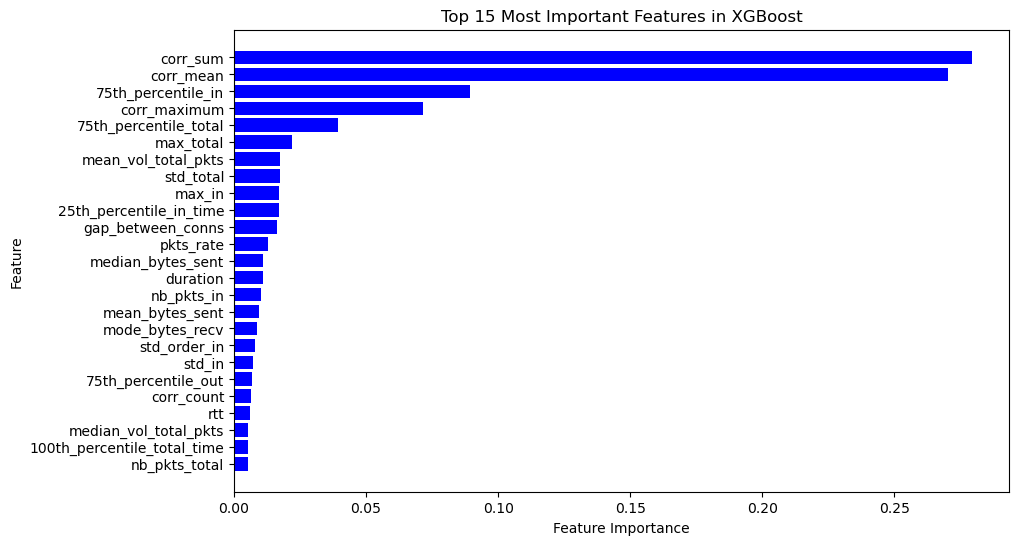

In [212]:
# Get feature importances
importances = xgb_model.feature_importances_

# Create a DataFrame for better sorting
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select the top 15 features
top_features = feature_importance_df.head(25)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="blue")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features in XGBoost")
plt.gca().invert_yaxis()  # Invert to show the most important on top
plt.show()


In [25]:
def process_df(df, background=True):
    # Add proper label
    df['label'] = 0 if background else 1
    
    # Remove unnecessary columns
    # columns_to_drop = ['mean_vol_total_pkts', 'conn', 'pcap_nb', 'mean_bytes_sent', 'mean_bytes_recv']
    # df.drop(columns = columns_to_drop, inplace=True)
    
    # Temporary change TODO: change later. To see affect of RTT
    columns_to_kepp = ['rtt', 'label']
    columns_to_drop = [column for column in df.columns if column not in columns_to_kepp]
    return df.drop(columns=columns_to_drop, inplace=True)
    


def process_rel_df(df):
    return process_df(df, False)

def process_bg_df(df):
    return process_df(df, True)

In [100]:
RANDOM_STATE = 42
#------------------------------------------------------------------------------
# Process pcaps: add labels and remove unnecessary columns
#------------------------------------------------------------------------------
# for rel_df in [rel_train, rel_val, rel_test]:
#     process_rel_df(rel_df)
    
# for bg_df in [bg_train, bg_val, bg_test]:
#     process_bg_df(bg_df)
    

# Combine relayed and background datasets
# train = pd.concat([rel_train, bg_train], ignore_index=True)
# val = pd.concat([rel_val, bg_val], ignore_index=True)
# test = pd.concat([rel_test, bg_test], ignore_index=True)


# Remove all columns with 0 std dev
# std_devs = train.std()
# features_to_keep = std_devs[std_devs != 0].index
# train = train[features_to_keep]
# val = val[features_to_keep]
# test = test[features_to_keep]

# Print shapes to verify splits
print(f"Training set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")

#------------------------------------------------------------------------------
# Balance the training dataset
#------------------------------------------------------------------------------
# Separate majority and minority classes
majority_class = train_df[train_df['label'] == 0]
minority_class = train_df[train_df['label'] == 1]



# Downsample majority class to reduce class imbalance (6:1 ratio)
desired_majority_size = int(len(minority_class) * 10)
majority_downsampled = resample(majority_class,
                              replace=False,
                              n_samples=desired_majority_size,
                              random_state=RANDOM_STATE)

# Print dataset shapes for verification

print("Training set shape:", majority_downsampled.shape[0] + minority_class.shape[0])
print("Test set shape:", test_df.shape[0])
print("Validation set shape:", val_df.shape[0])

# Create final balanced training dataset
train_balanced = pd.concat([majority_downsampled, minority_class])
train_balanced = train_balanced.dropna()

Training set shape: (994210, 160)
Validation set shape: (456967, 160)
Test set shape: (605106, 160)
Training set shape: 156101
Test set shape: 605106
Validation set shape: 456967


In [10]:
import os
import pickle
from datetime import datetime
import pandas as pd

# Create a timestamp for this experiment run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
base_results_dir = f'experiment_results_{timestamp}'
os.makedirs(base_results_dir, exist_ok=True)

# No data
# (False, 3)
# (True, 3)
# (True, 0)
# (True, 1)

# Define experiment configurations
configurations = [
    (False, 0), (False, 1), (False, 2), 
      (True, 2)
]

results_summary = []

for has_attack, setting_num in configurations:
    exp_name = f'{"with_attack" if has_attack else "no_attack"}_setting_{setting_num}'
    print(f"\nRunning experiment: {exp_name}")
    
    # Create directory for this specific experiment
    exp_dir = os.path.join(base_results_dir, exp_name)
    os.makedirs(exp_dir, exist_ok=True)
    
    # Get the data splits
    test_df, train_df, val_df = run_experiment_setting(has_attack, setting_num)
    
    # Reset indices to ensure they are unique
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    
    # Train the model
    predictor = train_main(train_df, val_df, "label", "medium_quality")
    
    # Prepare test data
    x_test = test_df.drop(columns=['label'])
    y_test = test_df['label']
    
    # Run testing
    res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = test_main(
        x_test, y_test, predictor, test_df, train_df, True
    )
    
    # Save all results
    results = {
        'predictor': predictor,
        'results': res1,
        'feature_importance': fimp1,
        'confusion_matrix': cmatrix,
        'predictions_proba': ypred_proba,
        'best_model': bestmodel,
        'performance': perf,
        'auc_score': auc_score,
        'mistakes': mistakes
    }
    
    # Save DataFrames as CSV
    test_df.to_csv(os.path.join(exp_dir, 'test_data.csv'), index=False)
    train_df.to_csv(os.path.join(exp_dir, 'train_data.csv'), index=False)
    val_df.to_csv(os.path.join(exp_dir, 'val_data.csv'), index=False)
    res1.to_csv(os.path.join(exp_dir, 'results.csv'), index=True)
    fimp1.to_csv(os.path.join(exp_dir, 'feature_importance.csv'), index=True)
    
    # Save other results using pickle
    with open(os.path.join(exp_dir, 'full_results.pkl'), 'wb') as f:
        pickle.dump(results, f)
    
    # Save experiment parameters and key metrics
    exp_summary = {
        'experiment': exp_name,
        'has_attack': has_attack,
        'setting_num': setting_num,
        'auc_score': auc_score,
        'best_model': bestmodel,
        'timestamp': timestamp
    }
    results_summary.append(exp_summary)

# Save overall summary
summary_df = pd.DataFrame(results_summary)
summary_df.to_csv(os.path.join(base_results_dir, 'experiments_summary.csv'), index=False)

print("\nAll experiments completed!")
print(f"Results saved in: {base_results_dir}")


Running experiment: no_attack_setting_0
(524307, 12)
(1383401, 153)


Verbosity: 3 (Detailed Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.16
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Feb 27 15:07:31 UTC 2025
CPU Count:          32
GPU Count:          1
Memory Avail:       34.63 GB / 62.50 GB (55.4%)
Disk Space Avail:   1094.03 GB / 1906.14 GB (57.4%)
Presets specified: ['medium_quality']
============ fit kwarg info ============
User Specified kwargs:
{'ag_args_fit': {'num_gpus': 1}, 'auto_stack': False, 'verbosity': 3}
Full kwargs:
{'_feature_generator_kwargs': None,
 '_save_bag_folds': None,
 'ag_args': None,
 'ag_args_ensemble': None,
 'ag_args_fit': {'num_gpus': 1},
 'auto_stack': False,
 'calibrate': 'auto',
 'delay_bag_sets': False,
 'ds_args': {'clean_up_fits': True,
             'detection_time_frac': 0.25,
             'enable_callbacks': False,
             'enable_ray_logging': True,
             'holdout_data': None,
     

[50]	valid_set's binary_logloss: 0.0265529	valid_set's f1: 0.856684
[100]	valid_set's binary_logloss: 0.0188246	valid_set's f1: 0.893036
[150]	valid_set's binary_logloss: 0.0157869	valid_set's f1: 0.908503
[200]	valid_set's binary_logloss: 0.0139571	valid_set's f1: 0.918623
[250]	valid_set's binary_logloss: 0.0127804	valid_set's f1: 0.925809
[300]	valid_set's binary_logloss: 0.0120293	valid_set's f1: 0.930164
[350]	valid_set's binary_logloss: 0.0113002	valid_set's f1: 0.934572
[400]	valid_set's binary_logloss: 0.0108319	valid_set's f1: 0.937129
[450]	valid_set's binary_logloss: 0.0103848	valid_set's f1: 0.939683
[500]	valid_set's binary_logloss: 0.0100222	valid_set's f1: 0.941898
[550]	valid_set's binary_logloss: 0.00967279	valid_set's f1: 0.944108
[600]	valid_set's binary_logloss: 0.00942786	valid_set's f1: 0.945538
[650]	valid_set's binary_logloss: 0.00921322	valid_set's f1: 0.946812
[700]	valid_set's binary_logloss: 0.00898276	valid_set's f1: 0.947763
[750]	valid_set's binary_loglos

Saving /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/LightGBMXT/model.pkl
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/utils/attr/LightGBMXT/y_pred_proba_val.pkl
	0.9644	 = Validation score   (f1)
	497.78s	 = Training   runtime
	8.23s	 = Validation runtime
	29575.9	 = Inference  throughput (rows/s | 243457 batch size)
Saving /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/trainer.pkl
Fitting model: LightGBM ...
	Fitting LightGBM with 'num_gpus': 1, 'num_cpus': 24
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	Fitting 10000 rounds... Hyperparameters: {'learning_rate': 0.05, 'device': 'gpu'}


[50]	valid_set's binary_logloss: 0.0199363	valid_set's f1: 0.906339
[100]	valid_set's binary_logloss: 0.0131474	valid_set's f1: 0.92659
[150]	valid_set's binary_logloss: 0.0108174	valid_set's f1: 0.937692
[200]	valid_set's binary_logloss: 0.00964112	valid_set's f1: 0.944487
[250]	valid_set's binary_logloss: 0.0106461	valid_set's f1: 0.947149
[300]	valid_set's binary_logloss: 0.010583	valid_set's f1: 0.947522
[350]	valid_set's binary_logloss: 0.0103851	valid_set's f1: 0.949806
[400]	valid_set's binary_logloss: 0.00991257	valid_set's f1: 0.952011
[450]	valid_set's binary_logloss: 0.00962196	valid_set's f1: 0.95279
[500]	valid_set's binary_logloss: 0.00936084	valid_set's f1: 0.954228
[550]	valid_set's binary_logloss: 0.0090867	valid_set's f1: 0.955823
[600]	valid_set's binary_logloss: 0.00887355	valid_set's f1: 0.956588
[650]	valid_set's binary_logloss: 0.0086965	valid_set's f1: 0.957196
[700]	valid_set's binary_logloss: 0.0085286	valid_set's f1: 0.958105
[750]	valid_set's binary_logloss:

...

[*]Model performance breakdown on Test data:
                  model  score_test  score_val eval_metric  pred_time_test  \
0   WeightedEnsemble_L2    0.846890   0.844121          f1       71.455586   
1         LightGBMLarge    0.831561   0.837152          f1       22.717788   
2               XGBoost    0.831106   0.836326          f1       11.556718   
3              CatBoost    0.821114   0.823246          f1        0.274400   
4            LightGBMXT    0.820873   0.824817          f1       35.827763   
5        NeuralNetTorch    0.817652   0.822470          f1        1.341479   
6      RandomForestEntr    0.806080   0.801970          f1        0.989638   
7        ExtraTreesEntr    0.803258   0.786542          f1        1.758805   
8        ExtraTreesGini    0.802367   0.784853          f1        1.663291   
9      RandomForestGini    0.796247   0.796561          f1        1.041836   
10             LightGBM    0.772564   0.787004          f1        1.695919   
11       KNeighbors

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/LightGBMXT/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/LightGBMXT/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/classification/AGmodels/models/WeightedEnsemble_L2/model.pkl
Skipp

[*]Predictions:  0         0
1         0
2         0
3         0
4         0
         ..
797489    0
797490    1
797491    1
797492    1
797493    0
Name: label, Length: 797494, dtype: int64
[*]Confidence in predictions:

               0             1
0       1.000000  2.666600e-08
1       1.000000  5.450073e-08
2       1.000000  4.059960e-10
3       1.000000  5.101692e-08
4       0.999985  1.502372e-05
...          ...           ...
797489  0.906827  9.317310e-02
797490  0.506508  4.934916e-01
797491  0.419061  5.809394e-01
797492  0.411131  5.888689e-01
797493  0.776490  2.235096e-01

[797494 rows x 2 columns]
Perf:  {'f1': 0.84688995215311, 'accuracy': 0.9959874306264374, 'balanced_accuracy': 0.8962188151167041, 'mcc': 0.8468302120035525, 'precision': 0.9078785391875257, 'recall': 0.7935796269727403}
{'0': {'precision': 0.9970777382557322, 'recall': 0.9988580032606678, 'f1-score': 0.9979670768089205, 'support': 786342.0}, '1': {'precision': 0.9078785391875257, 'recall': 0.793579626

These features in provided data are not utilized by the predictor and will be ignored: ['avg_out', 'avg_total', '100th_percentile_in_time', '25th_percentile_out_time', '50th_percentile_out_time', '75th_percentile_out_time', '100th_percentile_out_time', '25th_percentile_total_time', 'nb_pkts_in_f30', 'nb_pkts_in_l30', 'std_pkt_conc_out20', 'std_per_sec', 'std_order_out', 'medconc', 'med_per_sec', 'min_per_sec', 'max_per_sec', 'maxconc', 'perc_in', 'perc_out', 'sum_altconc', 'sum_alt_per_sec', 'sum_number_pkts', 'sum_intertimestats', 'altconc_1', 'altconc_2', 'altconc_3', 'altconc_4', 'altconc_5', 'altconc_6', 'altconc_7', 'altconc_8', 'altconc_9', 'altconc_10', 'altconc_11', 'altconc_12', 'altconc_13', 'altconc_14', 'altconc_15', 'altconc_16', 'altconc_17', 'altconc_18', 'altconc_19', 'altconc_20', 'alt_per_sec_1', 'alt_per_sec_2', 'alt_per_sec_3', 'alt_per_sec_4', 'alt_per_sec_5', 'alt_per_sec_6', 'alt_per_sec_7', 'alt_per_sec_8', 'alt_per_sec_9', 'alt_per_sec_10', 'alt_per_sec_11', 'a

Feature Importance on test data:                               importance    stddev       p_value  n  p99_high  \
75th_percentile_in             0.677473  0.096919  4.892140e-05  5  0.877031   
std_in                         0.645377  0.033593  8.777591e-07  5  0.714547   
75th_percentile_out            0.459219  0.016915  2.205151e-07  5  0.494047   
std_total                      0.371460  0.028747  4.270397e-06  5  0.430652   
75th_percentile_total          0.368447  0.042397  2.067175e-05  5  0.455742   
std_out                        0.309061  0.054794  1.137486e-04  5  0.421882   
max_total                      0.258293  0.030239  2.213605e-05  5  0.320556   
max_in                         0.239642  0.028285  2.286350e-05  5  0.297882   
max_out                        0.231805  0.028488  2.683099e-05  5  0.290462   
nb_pkts_total                  0.216965  0.028543  3.512883e-05  5  0.275735   
100th_percentile_total_time    0.215254  0.026636  2.757073e-05  5  0.270098   
nb_pkt

In [33]:
percentages = [0.025, 0.01, 0.007, 0.005, 0.002, 0.001]
negative_rows_len = len(negative_rows)
results_list = []

for percentage in percentages:
    # Only keep percentage amount of rows in positive class
    n_rows_to_keep = round(negative_rows_len * percentage)
    positive_rows_subset = keep_n_rows(positive_rows, n_rows_to_keep, RANDOM_STATE)
    test_subset = pd.concat([positive_rows_subset, negative_rows])
    
    # Ensure order of columns in test frame is same as train one
    test_subset = test_subset[train.columns]

    x_test = test_subset.drop(columns=['label'])
    y_test = test_subset['label']
    print(f"###################~Testing Trained Models: {percentage * 100}% with {len(positive_rows_subset)} rows" + "############################")
    # Uncomment for test results with feature importance (longer run time)
    # res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = test_main(x_test, y_test, predictor, test, train,True)
    results_list.append(test_main(x_test, y_test, predictor, test, train,True))

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsUnif/model.pkl


###################~Testing Trained Models: 2.5% with 4992 rows############################


Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/KNeighborsDist/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMXT/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBM/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/RandomForestGini/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/RandomForestEntr/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/ExtraTreesGini/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/ExtraTreesEntr/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetFastAI/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetFastAI/model-internals.pkl
Loading: /home/temoorali/Docum

[*]Model performance breakdown on Test data:
                  model  score_test  score_val eval_metric  pred_time_test  \
0   WeightedEnsemble_L2    0.977024   0.971396          f1        2.112544   
1              CatBoost    0.971123   0.963781          f1        0.039907   
2               XGBoost    0.970445   0.963916          f1        0.851519   
3        NeuralNetTorch    0.969157   0.961746          f1        1.153754   
4         LightGBMLarge    0.947263   0.941623          f1        0.061177   
5      RandomForestEntr    0.946200   0.935624          f1        0.251390   
6       NeuralNetFastAI    0.945336   0.935629          f1        1.111565   
7      RandomForestGini    0.945015   0.936289          f1        0.262012   
8              LightGBM    0.939217   0.929954          f1        0.052945   
9        ExtraTreesEntr    0.935033   0.923901          f1        0.311911   
10       ExtraTreesGini    0.934968   0.921981          f1        0.318165   
11           LightG

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Skipping roc_auc because no prediction probabilities are available to score.
These features in provided data are not utilized by the predictor and will be ignored: ['med_per_sec', 'alt_per_sec_9', 'alt_per_sec_10', 'alt_per_sec_12', 'alt_per_sec_13', 'alt_per_sec_14', 'alt_per_sec_15', 'alt_per_sec_18', 'alt_per_sec_19', 'conc_2',

...

[*]Model performance breakdown on Test data:
                  model  score_test  score_val eval_metric  pred_time_test  \
0   WeightedEnsemble_L2    0.977024   0.971396          f1        2.180699   
1              CatBoost    0.971123   0.963781          f1        0.044913   
2               XGBoost    0.970445   0.963916          f1        0.928025   
3        NeuralNetTorch    0.969157   0.961746          f1        1.138864   
4         LightGBMLarge    0.947263   0.941623          f1        0.061775   
5      RandomForestEntr    0.946200   0.935624          f1        0.252248   
6       NeuralNetFastAI    0.945336   0.935629          f1        1.645452   
7      RandomForestGini    0.945015   0.936289          f1        0.262424   
8              LightGBM    0.939217   0.929954          f1        0.048343   
9        ExtraTreesEntr    0.935033   0.923901          f1        0.368236   
10       ExtraTreesGini    0.934968   0.921981          f1        0.371666   
11           LightG

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Skipping roc_auc because no prediction probabilities are available to score.
These features in provided data are not utilized by the predictor and will be ignored: ['med_per_sec', 'alt_per_sec_9', 'alt_per_sec_10', 'alt_per_sec_12', 'alt_per_sec_13', 'alt_per_sec_14', 'alt_per_sec_15', 'alt_per_sec_18', 'alt_per_sec_19', 'conc_2',

[*]Predictions:  34        1
64        1
130       1
146       1
161       1
         ..
204693    0
204694    0
204695    0
204696    0
204697    0
Name: label, Length: 199862, dtype: int64
[*]Confidence in predictions:

               0         1
34      0.133214  0.866786
64      0.438067  0.561933
130     0.134512  0.865488
146     0.133214  0.866786
161     0.133225  0.866775
...          ...       ...
204693  0.977429  0.022571
204694  0.974149  0.025851
204695  0.977429  0.022571
204696  0.977429  0.022571
204697  0.977701  0.022299

[199862 rows x 2 columns]
Perf:  {'f1': 0.7095588235294118, 'accuracy': 0.9992094545236213, 'balanced_accuracy': 0.9821218609449971, 'mcc': 0.7354942191919515, 'precision': 0.561046511627907, 'recall': 0.965}
{'0': {'precision': 0.9999649154462255, 'recall': 0.9992437218899941, 'f1-score': 0.9996041885866025, 'support': 199662.0}, '1': {'precision': 0.561046511627907, 'recall': 0.965, 'f1-score': 0.7095588235294118, 'support': 200.0}, 'accuracy': 0.

Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
Computing feature importance via permutation shuffling for 82 features using 5000 rows with 5 shuffle sets...
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/NeuralNetTorch/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/XGBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/WeightedEnsemble_L2/model.pkl
	48.71s	= Expected runtime (9.74s per shuffle set)
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/CatBoost/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/LightGBMLarge/model.pkl
Loading: /home/temoorali/Documents/ProxyTrafficAnalysis/AGmodels/models/Ne

Feature Importance on test data:                              importance    stddev   p_value  n  p99_high  \
corr_mean                     0.120842  0.025247  0.000216  5  0.172827   
corr_sum                      0.081209  0.032987  0.002656  5  0.149131   
std_in                        0.059445  0.023305  0.002336  5  0.107431   
50th_percentile_out_time      0.039866  0.015475  0.002253  5  0.071730   
corr_count                    0.026292  0.003989  0.000062  5  0.034507   
...                                ...       ...       ... ..       ...   
nb_pkts_in_l30               -0.002323  0.006763  0.757358  5  0.011601   
nb_pkts_out_l30              -0.002324  0.003183  0.911053  5  0.004230   
50th_percentile_in_time      -0.002964  0.012489  0.688132  5  0.022751   
25th_percentile_total_time   -0.003377  0.003084  0.964738  5  0.002972   
std_pkt_conc_out20           -0.003828  0.008689  0.809812  5  0.014064   

                             p99_low  
corr_mean                 

In [16]:
print(os.getcwd())

/home/temoorali/Documents/ProxyTrafficAnalysis/classification


In [2]:
import pickle

BASE_PATH = "experiment_results_20250412_183243"
paths_list = ['no_attack_setting_0', 'no_attack_setting_2',]

paths_list = [f"{BASE_PATH}/{path}/full_results.pkl" for path in paths_list]


    # results = {
    #     'predictor': predictor,
    #     'results': res1,
    #     'feature_importance': fimp1,
    #     'confusion_matrix': cmatrix,
    #     'predictions_proba': ypred_proba,
    #     'best_model': bestmodel,
    #     'performance': perf,
    #     'auc_score': auc_score,
    #     'mistakes': mistakes
    # }

for path in paths_list:
    with open(path, 'rb') as file:
        res = pickle.load(file)
        predictor, res1, fimp1, cmatrix, ypred_proba, bestmodel, perf, auc_score, mistakes = res.values()

        print("=" * 15 + path + "=" * 15)
        f1 = perf['f1']
        precision = perf['precision']
        recall = perf['recall']
        
        print(f"f1: {100 * f1:.4f}")
        print(f"precision: {100 * precision:.4f}")
        print(f"recall: {100 * recall:.4f}")
        
        TN = cmatrix[0]  # True Negatives
        FP = cmatrix[1]  # False Positives
        FN = cmatrix[2]  # False Negatives 
        TP = cmatrix[3]  # True Positives
        
        # Calculate rates
        FPR = (FP / (FP + TN))*100 if (FP + TN) > 0 else 0
        FNR = (FN / (FN + TP))*100 if (FN + TP) > 0 else 0

        print(f"False Positive Rate (FPR): {FPR:.4f} %")
        print(f"False Negative Rate (FNR): {FNR:.4f} %")

===============experiment_results_20250412_183243/no_attack_setting_0/full_results.pkl===============
f1: 98.5835
precision: 99.2582
recall: 97.9180
False Positive Rate (FPR): 0.0224 %
False Negative Rate (FNR): 2.0820 %
===============experiment_results_20250412_183243/no_attack_setting_2/full_results.pkl===============
f1: 97.7316
precision: 98.6622
recall: 96.8183
False Positive Rate (FPR): 0.0179 %
False Negative Rate (FNR): 3.1817 %


In [111]:
TN = cmatrix[0]  # True Negatives
FP = cmatrix[1]  # False Positives
FN = cmatrix[2]  # False Negatives 
TP = cmatrix[3]  # True Positives


# The confusion matrix stored as a nested list:
cm = [[TN, FP],
      [FN, TP]]

# Create a DataFrame with custom row and column labels:
df_cm = pd.DataFrame(cm,
                     index=['Actual: 0', 'Actual: 1'],         # rows: actual classes
                     columns=['Predicted: 0', 'Predicted: 1'])   # columns: predicted classes

print("Confusion Matrix:")
print(df_cm)


Confusion Matrix:
           Predicted: 0  Predicted: 1
Actual: 0        595216           140
Actual: 1           440          9310


In [112]:
# For flattened confusion matrix list [TN, FP, FN, TP]
TN = cmatrix[0]  # True Negatives
FP = cmatrix[1]  # False Positives
FN = cmatrix[2]  # False Negatives 
TP = cmatrix[3]  # True Positives

# Calculate rates
FPR = (FP / (FP + TN))*100 if (FP + TN) > 0 else 0
FNR = (FN / (FN + TP))*100 if (FN + TP) > 0 else 0

# Debug prints
print(f"Confusion Matrix (flattened): [{TN}, {FP}, {FN}, {TP}]")
print(f"False Positive Rate (FPR): {FPR:.4f} %")
print(f"False Negative Rate (FNR): {FNR:.4f} %")

Confusion Matrix (flattened): [595216, 140, 440, 9310]
False Positive Rate (FPR): 0.0235 %
False Negative Rate (FNR): 4.5128 %


In [107]:
fimp1.head(10)

,importance,stddev,p_value,n,p99_high,p99_low
std_in,0.450118,0.037996,0.000006,5,0.528352,0.371884
corr_mean,0.304045,0.031116,0.000013,5,0.368114,0.239975
75th_percentile_total,0.150490,0.020668,0.000042,5,0.193046,0.107933
std_out,0.077668,0.017825,0.000311,5,0.114370,0.040966
corr_sum,0.067491,0.018303,0.000590,5,0.105177,0.029805
75th_percentile_in,0.067097,0.009640,0.000050,5,0.086946,0.047248
std_total,0.048940,0.015701,0.001114,5,0.081267,0.016612
corr_count,0.048581,0.022954,0.004544,5,0.095844,0.001318
75th_percentile_out,0.021417,0.008064,0.002016,5,0.038021,0.004813
corr_maximum,0.019096,0.006184,0.001153,5,0.031828,0.006364
